# Simulation Analysis: Species Distribution, Breeding Site Suitability & Validation

This notebook analyses **LivingAgent (mosquitoes)** and **InertAgent (water tanks)** from large snapshot CSV files (GB scale) on a laptop with 8 GB RAM. It produces:
- **Suitability maps** for adult mosquitoes and breeding sites (water tanks) – derived from KDE heatmaps and tank occupancy.
- **Validation** against real‑world occurrence data (GBIF / iNaturalist).
- **Life‑cycle validation** (stage durations, discrete‑time projection matrix λ_max).
- **Memory‑efficient** chunked processing and per‑tick spatial sampling.
- **Export of suitability rasters** (GeoTIFF) for further use in GIS (QGIS).

## Configuration

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from scipy.spatial import cKDTree
from scipy.stats import pearsonr
from scipy.signal import correlate, correlation_lags
from sklearn.neighbors import KernelDensity
from scipy.interpolate import RegularGridInterpolator
import rasterio
from rasterio.transform import from_origin
import os
import warnings
warnings.filterwarnings('ignore')

# ========== CONFIGURATION ==========
# --- EDIT THESE PATHS ---
INPUT_FILE = "/home/void/Documents/codes/monadvsim/results/merged_snapshots_20260424_185154.csv"
STUDY_AREA_FILE = "/home/void/Documents/codes/monadvsim/prepared_data/dire_dawa/dire_dawa.shp"
OUTPUT_DIR = "/mnt/monadworld/projects/phd/article_manuscripts/new/figs/"
# --- Occurrence data (GBIF / iNaturalist) ---
OCCURRENCE_FILE = "/mnt/monadworld/projects/phd/article_manuscripts/a_cdm_for_vector_of_vbds/data/datasets/gbif/anopheles_stephensi_ethiopia/0014832-260409193756587.csv"   # Set to a CSV or GeoJSON path, e.g., "occurrences.csv"
# If CSV, must contain columns 'longitude', 'latitude' (and optionally 'species')
# -------------------------
TICKS_PER_DAY = 96
CHUNKSIZE = 100000               # rows per chunk for daily aggregation
MAX_SPATIAL_POINTS_PER_TICK = 100000   # max points to read for a single tick (memory safe)
STAGE_COLORS = {'ADULT': '#2E8B57', 'LARVA': '#4169E1', 'PUPA': '#FF8C00'}

# ---- Environment variables to analyse (add/remove as needed) ----
ENV_VARS = [
    ('t2m', 'Temperature', '°C', lambda x: x, False),      # CSV already Celsius
    ('tp', 'Precipitation', 'mm', lambda x: x * 1000, True),
]

# ---- Export settings ----
EXPORT_RASTERS = True          # set to False to skip GeoTIFF export
KDE_BANDWIDTH_DEG = 0.002      # bandwidth in degrees (~220 m at equator)
KDE_GRID_RES = 200             # number of cells along the longer axis

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ========== LOAD STUDY AREA BASEMAP ==========
if os.path.exists(STUDY_AREA_FILE):
    study_area = gpd.read_file(STUDY_AREA_FILE)
    if study_area.crs is None:
        study_area.crs = "EPSG:4326"
    elif study_area.crs.to_epsg() != 4326:
        study_area = study_area.to_crs("EPSG:4326")
    print(f"Loaded study area basemap: {STUDY_AREA_FILE}")
    print(f"Bounds: {study_area.total_bounds}")
else:
    print(f"Study area file not found: {STUDY_AREA_FILE}. Spatial plots will be without basemap.")
    study_area = None

# ========== LOAD OCCURRENCE DATA (if provided) ==========
occurrences = None
if OCCURRENCE_FILE and os.path.exists(OCCURRENCE_FILE):
    if OCCURRENCE_FILE.endswith('.shp') or OCCURRENCE_FILE.endswith('.geojson'):
        occurrences = gpd.read_file(OCCURRENCE_FILE).to_crs("EPSG:4326")
    else:
        occ_df = pd.read_csv(OCCURRENCE_FILE, delimiter="\t")
        if 'longitude' in occ_df.columns and 'latitude' in occ_df.columns:
            occurrences = gpd.GeoDataFrame(occ_df, geometry=gpd.points_from_xy(occ_df.longitude, occ_df.latitude), crs="EPSG:4326")
        else:
            print("Occurrence CSV must contain 'longitude' and 'latitude' columns.")
    if occurrences is not None:
        print(f"Loaded {len(occurrences)} occurrence records.")
else:
    print("No occurrence file provided – validation plots will be skipped.")

# ========== DEFINE COLUMNS & DTYPES ==========
living_base_cols = ['TickCount', 'Stage', 'X', 'Y', 'AgentID', 'Age', 'Energy', 'Gravid']
env_col_names = [v[0] for v in ENV_VARS]
living_columns = living_base_cols + env_col_names
inert_columns = ['TickCount', 'X', 'Y', 'EggCount', 'LarvaCount', 'waterVolume', 'AgentID']

living_dtypes = {
    'TickCount': 'int32',
    'Stage': 'category',
    'X': 'float32',
    'Y': 'float32',
    'AgentID': 'object',
    'Age': 'int16',
    'Energy': 'float32',
    'Gravid': 'int8'
}
for col in env_col_names:
    living_dtypes[col] = 'float32'

inert_dtypes = {
    'TickCount': 'int32',
    'X': 'float32',
    'Y': 'float32',
    'EggCount': 'int32',
    'LarvaCount': 'int32',
    'waterVolume': 'float32',
    'AgentID': 'object'
}

print(f"Environment variables: {env_col_names}")
print("Configuration ready.")

Loaded study area basemap: /home/void/Documents/codes/monadvsim/prepared_data/dire_dawa/dire_dawa.shp
Bounds: [41.72802774  9.47148374 42.3397728   9.78374168]
Loaded 20 occurrence records.
Environment variables: ['t2m', 'tp']
Configuration ready.


## 1. Incremental Daily Aggregation (memory‑efficient)

In [20]:
def incremental_aggregation(filepath, living_cols, inert_cols, living_dtypes, inert_dtypes, 
                            env_vars, chunksize):
    """Process CSV in chunks, return daily aggregates."""
    daily_adults = {}
    daily_larvae = {}
    daily_pupae = {}
    daily_env_sum = {col: {} for col, _, _, _, _ in env_vars}
    daily_env_cnt = {col: {} for col, _, _, _, _ in env_vars}
    daily_tank_count = {}
    daily_water_sum = {}
    daily_water_cnt = {}
    daily_eggs_sum = {}
    daily_larvae_sum = {}
    min_tick = None
    max_tick = None
    
    print("Starting chunked processing...")
    chunk_iter = pd.read_csv(filepath, chunksize=chunksize, low_memory=False)
    
    for i, chunk in enumerate(chunk_iter):
        if i % 10 == 0:
            print(f"Processing chunk {i}...")
        tick_min = chunk['TickCount'].min()
        tick_max = chunk['TickCount'].max()
        if min_tick is None or tick_min < min_tick: min_tick = tick_min
        if max_tick is None or tick_max > max_tick: max_tick = tick_max
        
        # Living agents
        living_mask = chunk['AgentType'] == 'LivingAgent'
        living_chunk = chunk.loc[living_mask, living_cols].astype(living_dtypes)
        if not living_chunk.empty:
            living_chunk['Day'] = (living_chunk['TickCount'] / TICKS_PER_DAY).astype('int32')
            adult = living_chunk[living_chunk['Stage'] == 'ADULT'].groupby('Day').size()
            larva = living_chunk[living_chunk['Stage'] == 'LARVA'].groupby('Day').size()
            pupa = living_chunk[living_chunk['Stage'] == 'PUPA'].groupby('Day').size()
            for day, cnt in adult.items(): daily_adults[day] = daily_adults.get(day, 0) + cnt
            for day, cnt in larva.items(): daily_larvae[day] = daily_larvae.get(day, 0) + cnt
            for day, cnt in pupa.items(): daily_pupae[day] = daily_pupae.get(day, 0) + cnt
            for col, _, _, _, _ in env_vars:
                if col not in living_chunk.columns: continue
                col_sum = living_chunk.groupby('Day')[col].sum()
                col_cnt = living_chunk.groupby('Day')[col].count()
                for day, val in col_sum.items():
                    daily_env_sum[col][day] = daily_env_sum[col].get(day, 0) + val
                    daily_env_cnt[col][day] = daily_env_cnt[col].get(day, 0) + col_cnt[day]
        
        # Inert agents
        inert_mask = chunk['AgentType'] == 'InertAgent'
        inert_chunk = chunk.loc[inert_mask, inert_cols].astype(inert_dtypes)
        if not inert_chunk.empty:
            inert_chunk['Day'] = (inert_chunk['TickCount'] / TICKS_PER_DAY).astype('int32')
            tank_count = inert_chunk.groupby('Day')['AgentID'].nunique()
            water_sum = inert_chunk.groupby('Day')['waterVolume'].sum()
            water_cnt = inert_chunk.groupby('Day')['waterVolume'].count()
            eggs_sum = inert_chunk.groupby('Day')['EggCount'].sum()
            larvae_sum = inert_chunk.groupby('Day')['LarvaCount'].sum()
            for day, cnt in tank_count.items(): daily_tank_count[day] = daily_tank_count.get(day, 0) + cnt
            for day, val in water_sum.items():
                daily_water_sum[day] = daily_water_sum.get(day, 0) + val
                daily_water_cnt[day] = daily_water_cnt.get(day, 0) + water_cnt[day]
            for day, val in eggs_sum.items(): daily_eggs_sum[day] = daily_eggs_sum.get(day, 0) + val
            for day, val in larvae_sum.items(): daily_larvae_sum[day] = daily_larvae_sum.get(day, 0) + val
    
    all_days = sorted(set(daily_adults.keys()) | set(daily_larvae.keys()) | set(daily_pupae.keys()) |
                      set().union(*[daily_env_sum[col].keys() for col in daily_env_sum]) |
                      set(daily_tank_count.keys()))
    
    daily_living_df = pd.DataFrame({'Day': all_days})
    daily_living_df['AdultCount'] = daily_living_df['Day'].map(daily_adults).fillna(0).astype('int32')
    daily_living_df['LarvaCount'] = daily_living_df['Day'].map(daily_larvae).fillna(0).astype('int32')
    daily_living_df['PupaCount'] = daily_living_df['Day'].map(daily_pupae).fillna(0).astype('int32')
    
    for col, disp, unit, convert, is_precip in env_vars:
        mean_col = f'Mean{disp}'
        raw_mean = (daily_living_df['Day'].map(daily_env_sum[col]).fillna(0) /
                    daily_living_df['Day'].map(daily_env_cnt[col]).fillna(1))
        daily_living_df[mean_col] = convert(raw_mean).round(2 if not is_precip else 4)
    
    daily_inert_df = pd.DataFrame({'Day': all_days})
    daily_inert_df['TankCount'] = daily_inert_df['Day'].map(daily_tank_count).fillna(0).astype('int32')
    daily_inert_df['MeanWaterVolume'] = (daily_inert_df['Day'].map(daily_water_sum).fillna(0) /
                                         daily_inert_df['Day'].map(daily_water_cnt).fillna(1)).round(2)
    daily_inert_df['TotalEggs'] = daily_inert_df['Day'].map(daily_eggs_sum).fillna(0).astype('int64')
    daily_inert_df['TotalLarvae'] = daily_inert_df['Day'].map(daily_larvae_sum).fillna(0).astype('int64')
    
    print(f"Processed ticks {min_tick} to {max_tick}")
    return daily_living_df, daily_inert_df

daily_living, daily_inert = incremental_aggregation(
    INPUT_FILE, living_columns, inert_columns, living_dtypes, inert_dtypes, 
    ENV_VARS, CHUNKSIZE
)
print("\nDaily Living summary head:")
print(daily_living.head())
print("\nDaily Inert summary head:")
print(daily_inert.head())

Starting chunked processing...
Processing chunk 0...
Processing chunk 10...
Processing chunk 20...
Processing chunk 30...
Processing chunk 40...
Processing chunk 50...
Processing chunk 60...
Processing chunk 70...
Processing chunk 80...
Processing chunk 90...
Processing chunk 100...
Processing chunk 110...
Processing chunk 120...
Processing chunk 130...
Processing chunk 140...
Processing chunk 150...
Processing chunk 160...
Processing chunk 170...
Processing chunk 180...
Processing chunk 190...
Processed ticks 100 to 8600

Daily Living summary head:
   Day  AdultCount  LarvaCount  PupaCount  MeanTemperature  MeanPrecipitation
0    1      132492       54304      32834            21.89            11.9492
1    2      132492       54302      32834            21.89            11.9481
2    3      132488       54298      32836            21.89            11.9478
3    4      132480       54295      32835            21.89            11.9484
4    5      132476       54293      32834            2

## 2. Population Dynamics & Lifecycle Validation (Corrected Discrete Projection Matrix)

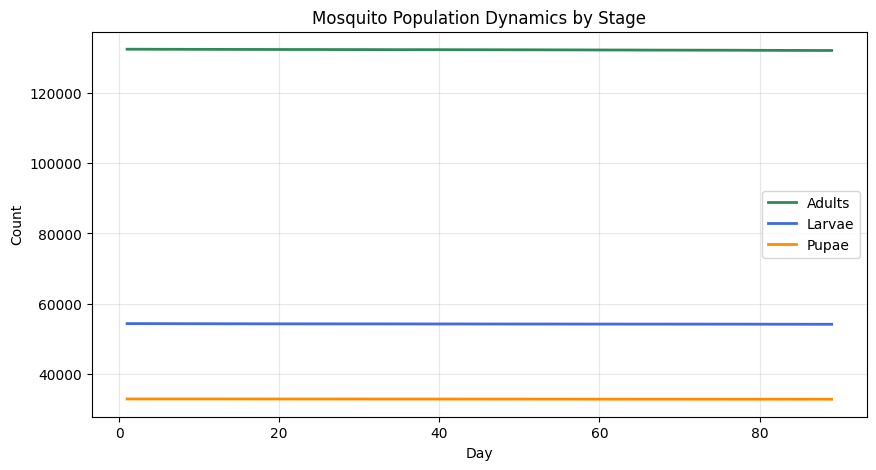

Estimated larval duration: 0.00 days
Estimated pupal duration: 0.00 days


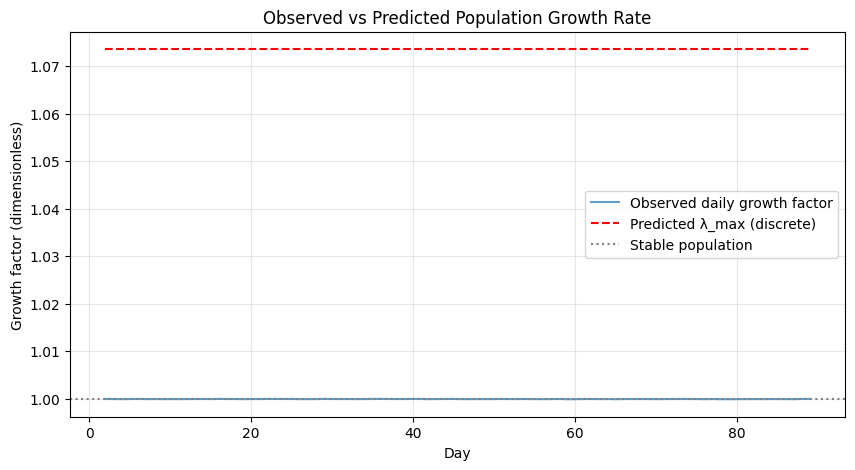

Average predicted λ_max: 1.074


In [21]:
# ---- Population dynamics plot ----
plt.figure(figsize=(10,5))
plt.plot(daily_living['Day'], daily_living['AdultCount'], label='Adults', color=STAGE_COLORS['ADULT'], linewidth=2)
plt.plot(daily_living['Day'], daily_living['LarvaCount'], label='Larvae', color=STAGE_COLORS['LARVA'], linewidth=2)
plt.plot(daily_living['Day'], daily_living['PupaCount'], label='Pupae', color=STAGE_COLORS['PUPA'], linewidth=2)
plt.xlabel('Day')
plt.ylabel('Count')
plt.title('Mosquito Population Dynamics by Stage')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/mosquito_dynamics.png', dpi=300, bbox_inches='tight')
plt.show()

# ---- Stage duration estimation (cross‑correlation) ----
larvae_vals = daily_living['LarvaCount'].values
pupae_vals = daily_living['PupaCount'].values
adult_vals2 = daily_living['AdultCount'].values
lags = correlation_lags(len(larvae_vals), len(pupae_vals))
ccf_lp = correlate(larvae_vals - larvae_vals.mean(), pupae_vals - pupae_vals.mean(), mode='full')
lag_lp = lags[np.argmax(ccf_lp)] / TICKS_PER_DAY
ccf_pa = correlate(pupae_vals - pupae_vals.mean(), adult_vals2 - adult_vals2.mean(), mode='full')
lag_pa = lags[np.argmax(ccf_pa)] / TICKS_PER_DAY
print(f"Estimated larval duration: {lag_lp:.2f} days")
print(f"Estimated pupal duration: {lag_pa:.2f} days")

# ---- Discrete projection matrix (daily) for growth rate validation ----
def discrete_lambda_max(T_C, livestock_density, params):
    # Fecundity
    term1 = params['fecundity_a'] * np.exp(params['fecundity_b'] * T_C)
    term2 = np.exp(params['fecundity_b'] * params['fecundity_Tmax'] - 
                   ((params['fecundity_Tmax'] - T_C) / params['fecundity_c'])**2)
    F = max(0, term1 - term2)
    
    # Development rates (1/day)
    dE = max(0, params['egg_dev_a']*T_C**2 + params['egg_dev_b']*T_C + params['egg_dev_c'])
    dL = max(0, params['larva_dev_a']*T_C**2 + params['larva_dev_b']*T_C + params['larva_dev_c'])
    dP = max(0, params['pupa_dev_a']*T_C**2 + params['pupa_dev_b']*T_C + params['pupa_dev_c'])
    
    # Adult mortality (1/day)
    muA = max(0, params['adult_mort_a']*T_C**2 + params['adult_mort_b']*T_C + params['adult_mort_c'])
    
    # Stage survival (probability over entire stage)
    SE = params['egg_survival_amp'] * np.exp(-0.5 * ((T_C - params['egg_survival_mean'])/params['egg_survival_sigma'])**2)
    SL = params['larva_survival_amp'] * np.exp(-0.5 * ((T_C - params['larva_survival_mean'])/params['larva_survival_sigma'])**2)
    SP = params['pupa_survival_amp'] * np.exp(-0.5 * ((T_C - params['pupa_survival_mean'])/params['pupa_survival_sigma'])**2)
    
    # Host carrying capacity
    K = 1 + np.log1p(max(0, livestock_density))
    
    # Discrete projection matrix (daily time step)
    A = np.array([
        [(1 - dE) * SE, 0, 0, F * K],
        [dE * SE, (1 - dL) * SL, 0, 0],
        [0, dL * SL, (1 - dP) * SP, 0],
        [0, 0, dP * SP, 1 - muA]
    ])
    eigvals = np.linalg.eigvals(A)
    return np.max(eigvals.real)

# Parameters (as defined in your simulation)
params = {
    'fecundity_a':0.378, 'fecundity_b':0.173, 'fecundity_Tmax':40.0, 'fecundity_c':2.97,
    'egg_dev_a':-0.0009, 'egg_dev_b':0.048, 'egg_dev_c':-0.345,
    'larva_dev_a':-0.0007, 'larva_dev_b':0.039, 'larva_dev_c':-0.32,
    'pupa_dev_a':-0.0005, 'pupa_dev_b':0.026, 'pupa_dev_c':-0.2,
    'egg_survival_amp':1.01, 'egg_survival_mean':24.5, 'egg_survival_sigma':4.8,
    'larva_survival_amp':0.95, 'larva_survival_mean':27.0, 'larva_survival_sigma':3.5,
    'pupa_survival_amp':0.93, 'pupa_survival_mean':26.8, 'pupa_survival_sigma':3.8,
    'adult_mort_a':-0.00065, 'adult_mort_b':0.0364, 'adult_mort_c':-0.4882
}

# Use a moderate livestock density (e.g., 0.5) as proxy
livestock_density = 0.5

# Find temperature column
temp_col = None
for col, disp, _, _, _ in ENV_VARS:
    if 'temp' in col.lower() or disp.lower() == 'temperature':
        temp_col = f'Mean{disp}'
        break

if temp_col is not None and temp_col in daily_living.columns:
    lambda_vals = [discrete_lambda_max(temp, livestock_density, params) for temp in daily_living[temp_col]]
    # Observed daily growth factor (ratio)
    adult_counts = daily_living['AdultCount'].values
    observed_growth = adult_counts[1:] / (adult_counts[:-1] + 1e-6)
    days_obs = daily_living['Day'].values[1:]
    
    plt.figure(figsize=(10,5))
    plt.plot(days_obs, observed_growth, label='Observed daily growth factor', alpha=0.7)
    plt.plot(days_obs, lambda_vals[1:], label='Predicted λ_max (discrete)', linestyle='--', color='red')
    plt.axhline(1, color='gray', linestyle=':', label='Stable population')
    plt.xlabel('Day'); plt.ylabel('Growth factor (dimensionless)')
    plt.title('Observed vs Predicted Population Growth Rate')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.savefig(f'{OUTPUT_DIR}/growth_validation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print average λ_max
    print(f"Average predicted λ_max: {np.mean(lambda_vals):.3f}")
else:
    print("No temperature variable – skipping Metzler validation.")

## 3. Water Tank Statistics

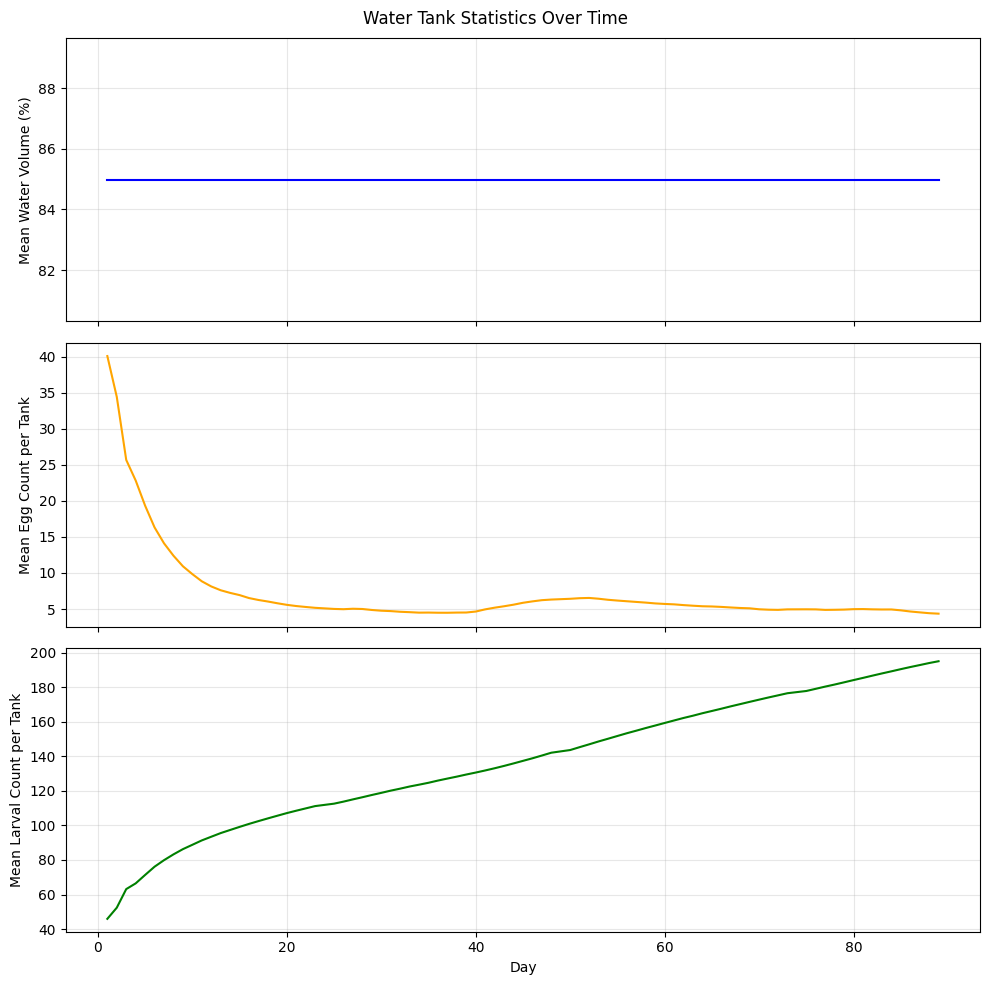

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
axes[0].plot(daily_inert['Day'], daily_inert['MeanWaterVolume'], color='blue')
axes[0].set_ylabel('Mean Water Volume (%)'); axes[0].grid(True, alpha=0.3)
axes[1].plot(daily_inert['Day'], daily_inert['TotalEggs'] / daily_inert['TankCount'].clip(lower=1), color='orange')
axes[1].set_ylabel('Mean Egg Count per Tank'); axes[1].grid(True, alpha=0.3)
axes[2].plot(daily_inert['Day'], daily_inert['TotalLarvae'] / daily_inert['TankCount'].clip(lower=1), color='green')
axes[2].set_ylabel('Mean Larval Count per Tank'); axes[2].set_xlabel('Day'); axes[2].grid(True, alpha=0.3)
plt.suptitle('Water Tank Statistics Over Time')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/tank_stats.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Environmental Correlation

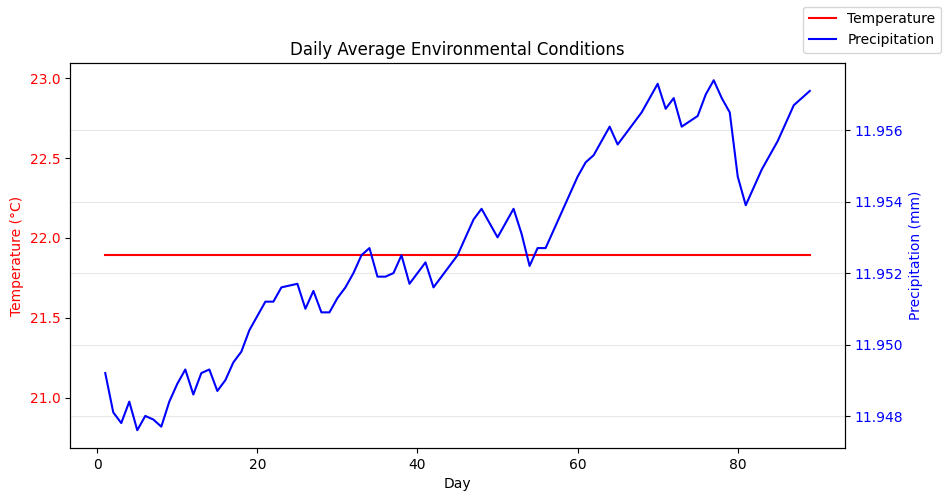

Correlation adult count vs Temperature: r=nan (p=nan)
Correlation adult count vs Precipitation: r=-0.935 (p=1.619e-39)


In [23]:
if len(ENV_VARS) == 1:
    col, disp, unit, _, _ = ENV_VARS[0]
    mean_col = f'Mean{disp}'
    plt.figure(figsize=(10,5))
    plt.plot(daily_living['Day'], daily_living[mean_col], color='red')
    plt.ylabel(f'{disp} ({unit})', color='red')
    plt.xlabel('Day'); plt.title(f'Daily Average {disp}'); plt.grid(True, alpha=0.3)
    plt.savefig(f'{OUTPUT_DIR}/environment.png', dpi=300, bbox_inches='tight'); plt.show()
else:
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.set_xlabel('Day')
    axes = [ax1]; colors = ['red','blue','green','orange','purple']
    for i, (col, disp, unit, _, _) in enumerate(ENV_VARS):
        mean_col = f'Mean{disp}'
        if i == 0:
            ax = ax1
            ax.set_ylabel(f'{disp} ({unit})', color=colors[i]); ax.tick_params(axis='y', labelcolor=colors[i])
        else:
            ax = ax1.twinx()
            ax.set_ylabel(f'{disp} ({unit})', color=colors[i]); ax.tick_params(axis='y', labelcolor=colors[i])
            axes.append(ax)
        ax.plot(daily_living['Day'], daily_living[mean_col], color=colors[i], label=disp)
    fig.legend(loc='upper right')
    plt.title('Daily Average Environmental Conditions')
    plt.grid(True, alpha=0.3)
    plt.savefig(f'{OUTPUT_DIR}/environment.png', dpi=300, bbox_inches='tight'); plt.show()

adult_series = daily_living['AdultCount'].values
for col, disp, unit, _, _ in ENV_VARS:
    mean_col = f'Mean{disp}'
    if mean_col in daily_living.columns:
        var_series = daily_living[mean_col].values
        corr, p = pearsonr(adult_series, var_series)
        print(f"Correlation adult count vs {disp}: r={corr:.3f} (p={p:.3e})")

## 5. Suitability Maps (Hotspots & Breeding Site Potential) + GeoTIFF Export

Adult points collected: 200000
Using last tick 100 for tank load.
Tank load data collected: 4820 tanks
Adult suitability raster saved to /mnt/monadworld/projects/phd/article_manuscripts/new/figs/adult_suitability.tif


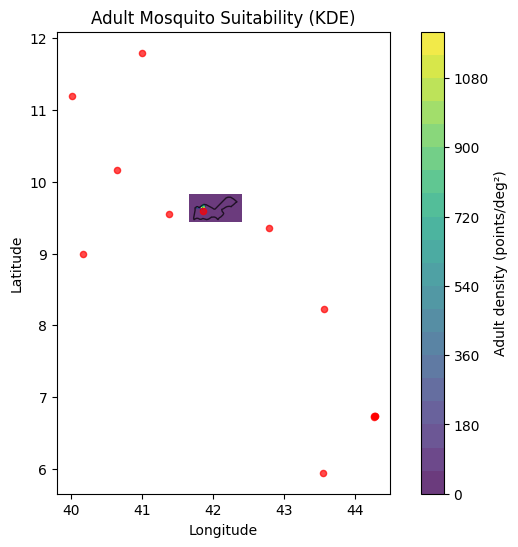

Breeding site potential raster saved to /mnt/monadworld/projects/phd/article_manuscripts/new/figs/breeding_site_potential.tif


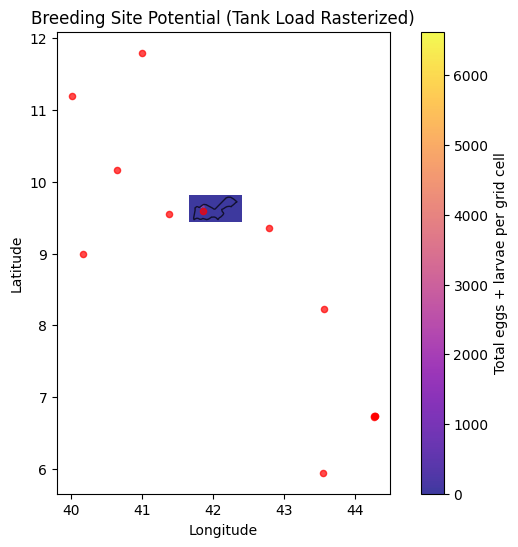

In [26]:
# Helper to read points across all ticks (memory‑efficient)
def accumulate_points(filepath, agent_type, stage=None, max_points=None):
    usecols = ['TickCount', 'AgentType', 'X', 'Y', 'Stage']
    all_points = []
    total = 0
    for chunk in pd.read_csv(filepath, chunksize=CHUNKSIZE, usecols=usecols, low_memory=False):
        mask = (chunk['AgentType'] == agent_type)
        if stage is not None:
            mask = mask & (chunk['Stage'] == stage)
        sub = chunk.loc[mask, ['X', 'Y']]
        if not sub.empty:
            all_points.append(sub)
            total += len(sub)
            if max_points and total >= max_points:
                break
    if not all_points:
        return pd.DataFrame()
    result = pd.concat(all_points, ignore_index=True)
    if max_points and len(result) > max_points:
        result = result.sample(n=max_points, random_state=42)
    return result

# Collect adult points (use a sample to keep memory manageable)
MAX_KDE_POINTS = 200000
adult_points = accumulate_points(INPUT_FILE, 'LivingAgent', stage='ADULT', max_points=MAX_KDE_POINTS)
print(f"Adult points collected: {len(adult_points)}")

# Also need tank loads for a representative tick (last tick)
last_tick = None
for chunk in pd.read_csv(INPUT_FILE, chunksize=CHUNKSIZE, usecols=['TickCount', 'AgentType'], low_memory=False):
    last_tick = chunk['TickCount'].max()
    break
print(f"Using last tick {last_tick} for tank load.")
tanks_load = []
for chunk in pd.read_csv(INPUT_FILE, chunksize=CHUNKSIZE, usecols=['TickCount', 'AgentType', 'X', 'Y', 'EggCount', 'LarvaCount'], low_memory=False):
    mask = (chunk['TickCount'] == last_tick) & (chunk['AgentType'] == 'InertAgent')
    sub = chunk.loc[mask, ['X', 'Y', 'EggCount', 'LarvaCount']]
    if not sub.empty:
        tanks_load.append(sub)
        if sum(len(df) for df in tanks_load) > 200000:  # cap
            break
if tanks_load:
    tanks_load_df = pd.concat(tanks_load, ignore_index=True)
    tanks_load_df['Load'] = tanks_load_df['EggCount'] + tanks_load_df['LarvaCount']
else:
    tanks_load_df = pd.DataFrame()
print(f"Tank load data collected: {len(tanks_load_df)} tanks")

# ---- KDE for adult mosquitoes ----
def create_kde_suitability(points, bandwidth_deg=KDE_BANDWIDTH_DEG, grid_res=KDE_GRID_RES):
    if len(points) < 10:
        return None, None, None, None
    if study_area is not None:
        bounds = study_area.total_bounds
        xmin, ymin, xmax, ymax = bounds
    else:
        xmin, xmax = points['X'].min(), points['X'].max()
        ymin, ymax = points['Y'].min(), points['Y'].max()
    # Add a small margin (10%)
    dx = (xmax - xmin) * 0.1
    dy = (ymax - ymin) * 0.1
    xmin -= dx; xmax += dx; ymin -= dy; ymax += dy
    x = np.linspace(xmin, xmax, grid_res)
    y = np.linspace(ymin, ymax, grid_res)
    xx, yy = np.meshgrid(x, y)
    grid = np.vstack([xx.ravel(), yy.ravel()]).T
    kde = KernelDensity(bandwidth=bandwidth_deg, metric='euclidean')
    kde.fit(points[['X','Y']].values)
    log_dens = kde.score_samples(grid)
    dens = np.exp(log_dens).reshape(xx.shape)
    return xx, yy, dens, (xmin, xmax, ymin, ymax)

adult_kde = create_kde_suitability(adult_points)

# ---- Plot and export rasters ----
if adult_kde[0] is not None:
    xx, yy, dens, (xmin, xmax, ymin, ymax) = adult_kde
    # Export adult suitability GeoTIFF
    if EXPORT_RASTERS:
        transform = from_origin(xmin, ymax, (xmax-xmin)/dens.shape[1], (ymax-ymin)/dens.shape[0])
        adult_tif = os.path.join(OUTPUT_DIR, 'adult_suitability.tif')
        with rasterio.open(adult_tif, 'w', driver='GTiff', height=dens.shape[0], width=dens.shape[1],
                           count=1, dtype=dens.dtype, crs='EPSG:4326', transform=transform) as dst:
            dst.write(dens, 1)
        print(f"Adult suitability raster saved to {adult_tif}")
    
    # Plot adult suitability
    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, dens, levels=20, cmap='viridis', alpha=0.8)
    if study_area is not None:
        study_area.boundary.plot(ax=plt.gca(), color='black', linewidth=1, alpha=0.7)
    if occurrences is not None:
        # occurrences.geometry.boundary.plot(ax=plt.gca(), color='red', marker='o', markersize=20, alpha=0.7, label='Occurrences')
        occurrences.plot(ax=plt.gca(), color='red', marker='o', markersize=20, alpha=0.7, label='Occurrences')
    plt.colorbar(label='Adult density (points/deg²)')
    plt.title('Adult Mosquito Suitability (KDE)')
    plt.xlabel('Longitude'); plt.ylabel('Latitude')
    plt.savefig(f'{OUTPUT_DIR}/adult_suitability.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Insufficient adult points for KDE.")

# ---- Breeding site potential (tank load) as raster (simple grid accumulation) ----
if not tanks_load_df.empty and EXPORT_RASTERS:
    if adult_kde[0] is not None:
        _, _, _, (xmin, xmax, ymin, ymax) = adult_kde
    elif study_area is not None:
        bounds = study_area.total_bounds
        xmin, ymin, xmax, ymax = bounds
        dx = (xmax - xmin) * 0.1
        dy = (ymax - ymin) * 0.1
        xmin -= dx; xmax += dx; ymin -= dy; ymax += dy
    else:
        xmin, xmax = tanks_load_df['X'].min(), tanks_load_df['X'].max()
        ymin, ymax = tanks_load_df['Y'].min(), tanks_load_df['Y'].max()
        dx = (xmax - xmin) * 0.1
        dy = (ymax - ymin) * 0.1
        xmin -= dx; xmax += dx; ymin -= dy; ymax += dy

    grid_res = KDE_GRID_RES
    x_edges = np.linspace(xmin, xmax, grid_res + 1)
    y_edges = np.linspace(ymin, ymax, grid_res + 1)
    
    col_idx = np.digitize(tanks_load_df['X'], x_edges) - 1
    row_idx = np.digitize(tanks_load_df['Y'], y_edges) - 1
    
    load_raster = np.zeros((grid_res, grid_res), dtype=np.float32)
    for r, c, load in zip(row_idx, col_idx, tanks_load_df['Load']):
        if 0 <= r < grid_res and 0 <= c < grid_res:
            load_raster[r, c] += load
    
    transform = from_origin(xmin, ymax, (xmax - xmin) / grid_res, (ymax - ymin) / grid_res)
    tank_tif = os.path.join(OUTPUT_DIR, 'breeding_site_potential.tif')
    with rasterio.open(tank_tif, 'w', driver='GTiff', height=grid_res, width=grid_res,
                       count=1, dtype=load_raster.dtype, crs='EPSG:4326', transform=transform) as dst:
        dst.write(load_raster, 1)
    print(f"Breeding site potential raster saved to {tank_tif}")
    
    plt.figure(figsize=(8,6))
    im = plt.imshow(load_raster, extent=[xmin, xmax, ymin, ymax], origin='lower', cmap='plasma', alpha=0.8)
    if study_area is not None:
        study_area.boundary.plot(ax=plt.gca(), color='black', linewidth=1, alpha=0.7)
    if occurrences is not None:
        # occurrences.geometry.boundary.plot(ax=plt.gca(), color='red', marker='o', markersize=20, alpha=0.7, label='Occurrences')
        occurrences.plot(ax=plt.gca(), color='red', marker='o', markersize=20, alpha=0.7, label='Occurrences')
    plt.colorbar(im, label='Total eggs + larvae per grid cell')
    plt.title('Breeding Site Potential (Tank Load Rasterized)')
    plt.xlabel('Longitude'); plt.ylabel('Latitude')
    plt.savefig(f'{OUTPUT_DIR}/breeding_site_potential.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No tank load data – cannot export breeding site raster.")

### Boyce Index Validation.

Continuous Boyce Index = 0.378
Interpretation: Model has good predictive ability (>0).


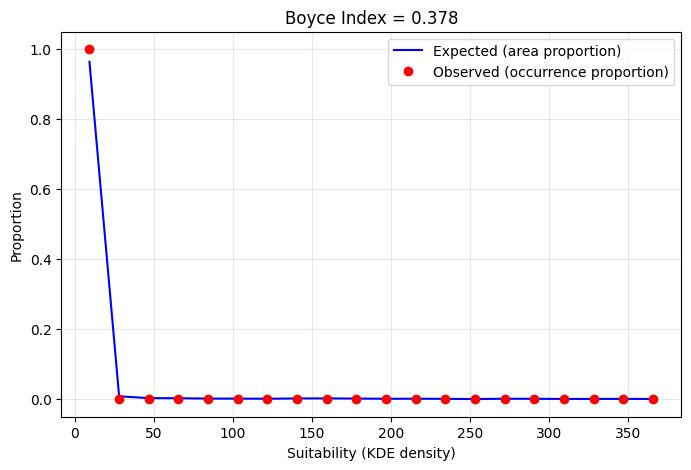

In [27]:
# ========== Continuous Boyce Index for Suitability Validation ==========
def continuous_boyce_index(suitability_raster, suit_x, suit_y, occurrences_gdf, n_bins=20, study_area_mask=None):
    """
    Calculate continuous Boyce index for presence-only validation.
    
    Parameters
    ----------
    suitability_raster : 2D array (lat x lon)
        Suitability density values.
    suit_x : 1D array
        Longitude coordinates of raster grid (size = n_lon).
    suit_y : 1D array
        Latitude coordinates of raster grid (size = n_lat).
    occurrences_gdf : GeoDataFrame
        Point geometries of occurrence records.
    n_bins : int
        Number of bins to partition the suitability range.
    study_area_mask : 2D boolean array (optional)
        Mask of the study area (True inside). If None, all cells are considered.
        
    Returns
    -------
    boyce_index : float
        Continuous Boyce index (range -1 to 1). Values >0 indicate good fit.
    bin_df : DataFrame
        Observed and expected frequencies per bin for plotting.
    """
    from scipy.stats import spearmanr
    
    # Extract suitability values at occurrence points
    occ_coords = np.array([[geom.x, geom.y] for geom in occurrences_gdf.geometry])
    from scipy.interpolate import RegularGridInterpolator
    interp = RegularGridInterpolator((suit_y, suit_x), suitability_raster, 
                                     bounds_error=False, fill_value=0)
    occ_suit = interp(occ_coords[:, [1,0]])  # (y,x)
    
    # Suitability values and area of each cell (if masking)
    # Create mask: if no study area mask, use all cells
    if study_area_mask is None:
        study_area_mask = np.ones_like(suitability_raster, dtype=bool)
    suit_flat = suitability_raster[study_area_mask]
    
    # Bin edges
    suit_min, suit_max = np.percentile(suit_flat, [1, 99])  # ignore extreme tails
    if suit_min == suit_max:
        suit_min = suit_flat.min()
        suit_max = suit_flat.max()
    bins = np.linspace(suit_min, suit_max, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Expected frequency: proportion of total area in each bin
    bin_idx = np.digitize(suit_flat, bins, right=False)
    area_per_bin = np.bincount(bin_idx, minlength=n_bins+1)[1:n_bins+1]
    expected_freq = area_per_bin / area_per_bin.sum()
    
    # Observed frequency: proportion of occurrence points in each bin
    occ_bin_idx = np.digitize(occ_suit, bins, right=False)
    occ_per_bin = np.bincount(occ_bin_idx, minlength=n_bins+1)[1:n_bins+1]
    observed_freq = occ_per_bin / occ_per_bin.sum()
    
    # Remove bins where expected frequency is zero (should not happen if bins cover full range)
    valid = expected_freq > 0
    if not valid.any():
        return np.nan, None
    
    # Continuous Boyce index = Spearman correlation between observed and expected frequencies
    boyce_idx, p_value = spearmanr(observed_freq[valid], expected_freq[valid])
    
    # Prepare output DataFrame
    bin_df = pd.DataFrame({
        'bin_center': bin_centers[valid],
        'expected_freq': expected_freq[valid],
        'observed_freq': observed_freq[valid],
        'F_ratio': observed_freq[valid] / expected_freq[valid]
    })
    
    return boyce_idx, bin_df

# Compute Boyce index using the adult suitability raster
if adult_kde[0] is not None and occurrences is not None:
    xx, yy, dens, _ = adult_kde
    # Optionally create a study area mask (e.g., from the shapefile)
    if study_area is not None:
        from shapely.geometry import Point
        # Rasterize the study area polygon onto the KDE grid
        study_mask = np.zeros_like(dens, dtype=bool)
        x_centers = xx[0,:]
        y_centers = yy[:,0]
        for i, lat in enumerate(y_centers):
            for j, lon in enumerate(x_centers):
                if study_area.geometry.contains(Point(lon, lat)).any():
                    study_mask[i,j] = True
    else:
        study_mask = None
    
    boyce_idx, bin_table = continuous_boyce_index(dens, x_centers, y_centers, occurrences, 
                                                  n_bins=20, study_area_mask=study_mask)
    print(f"Continuous Boyce Index = {boyce_idx:.3f}")
    if boyce_idx > 0:
        print("Interpretation: Model has good predictive ability (>0).")
    else:
        print("Interpretation: Model predictive ability is poor (<=0).")
    
    # Plot observed vs expected frequency
    if bin_table is not None:
        fig, ax = plt.subplots(figsize=(8,5))
        ax.plot(bin_table['bin_center'], bin_table['expected_freq'], 'b-', label='Expected (area proportion)')
        ax.plot(bin_table['bin_center'], bin_table['observed_freq'], 'ro', label='Observed (occurrence proportion)')
        ax.set_xlabel('Suitability (KDE density)')
        ax.set_ylabel('Proportion')
        ax.set_title(f'Boyce Index = {boyce_idx:.3f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.savefig(f'{OUTPUT_DIR}/boyce_index.png', dpi=300, bbox_inches='tight')
        plt.show()
else:
    print("Cannot compute Boyce index – either suitability KDE or occurrence data missing.")

## 6. Validation against Real Occurrence Data

In [ ]:
if occurrences is not None and adult_kde[0] is not None:
    xx, yy, dens, _ = adult_kde
    occ_coords = np.array([[geom.x, geom.y] for geom in occurrences.geometry])
    x_grid = xx[0,:]
    y_grid = yy[:,0]
    interpolator = RegularGridInterpolator((y_grid, x_grid), dens, bounds_error=False, fill_value=0)
    occ_dens = interpolator(occ_coords[:, [1,0]])
    threshold = np.percentile(dens[dens>0], 80)
    high_suit = occ_dens >= threshold
    accuracy = np.mean(high_suit) * 100
    print(f"Proportion of occurrence points in top 20% adult suitability: {accuracy:.1f}%")
    plt.figure(figsize=(6,4))
    plt.hist(occ_dens, bins=20, alpha=0.7, edgecolor='black')
    plt.axvline(threshold, color='red', linestyle='--', label='80th percentile threshold')
    plt.xlabel('Adult suitability density'); plt.ylabel('Number of occurrence points')
    plt.title('Validation: Occurrence Points vs Simulated Suitability')
    plt.legend()
    plt.savefig(f'{OUTPUT_DIR}/validation_histogram.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Occurrence data or suitability KDE missing – cannot compute validation.")

## 7. Export Tidy Data (daily summary & sample)

In [ ]:
daily_summary = pd.merge(daily_living, daily_inert, on='Day', how='outer')
daily_summary.to_csv(f'{OUTPUT_DIR}/daily_summary.csv', index=False)
sample_df = pd.read_csv(INPUT_FILE, nrows=10000)
sample_df.to_csv(f'{OUTPUT_DIR}/living_sample.csv', index=False)
print(f"Summaries saved to {OUTPUT_DIR}/")
print("Files: daily_summary.csv, living_sample.csv")

In [ ]:
print("Analysis complete. All figures and rasters saved.")